In [7]:

import pandas as pd
import matplotlib.pyplot as plt

csv_path = "results_database.csv"
df = pd.read_csv(csv_path)

# Filter to in-domain only
in_domain = df[df['train_task'] == df['test_task']].copy()

# Prepare filtered datasets for each condition
no_prompt_data = df[
    (df['train_task'] == df['test_task']) &
    (df['train_condition'] == 'no-prompt') &
    (df['test_condition'] == 'no-prompt')
].copy()

cot_data = df[
    (df['train_task'] == df['test_task']) &
    (df['train_condition'] == 'cot-zero-shot') &
    (df['test_condition'] == 'cot-zero-shot')
].copy()

sentence_based_cot_data = df[
    (df['train_task'] == df['test_task']) &
    (df['train_condition'] == 'sentence-based-CoT') &
    (df['test_condition'] == 'sentence-based-CoT')
].copy()

# Define styling
style_map = {
    "F0": {"color": "#2ca02c", "marker": "o"},
    "F1": {"color": "#9467bd", "marker": "s"},
    "F2": {"color": "#8c564b", "marker": "^"},
    "F3": {"color": "#e377c2", "marker": "D"},
    "F4": {"color": "#d62728", "marker": "v"},
    "F5": {"color": "#7f7f7f", "marker": "P"},
    "A1": {"color": "#1f77b4", "marker": "*"},
    "A2": {"color": "#ff7f0e", "marker": "X"},
    "A3": {"color": "#17becf", "marker": "h"},
}

print("✓ Data loaded and prepared")
print(f"  No-prompt rows: {len(no_prompt_data)}")
print(f"  COT-Zero-Shot rows: {len(cot_data)}")
print(f"  Sentence-Based-CoT rows: {len(sentence_based_cot_data)}")

✓ Data loaded and prepared
  No-prompt rows: 297
  COT-Zero-Shot rows: 297
  Sentence-Based-CoT rows: 297


Models in CSV: <StringArray>
['deepseek-r1-distill-8b']
Length: 1, dtype: str


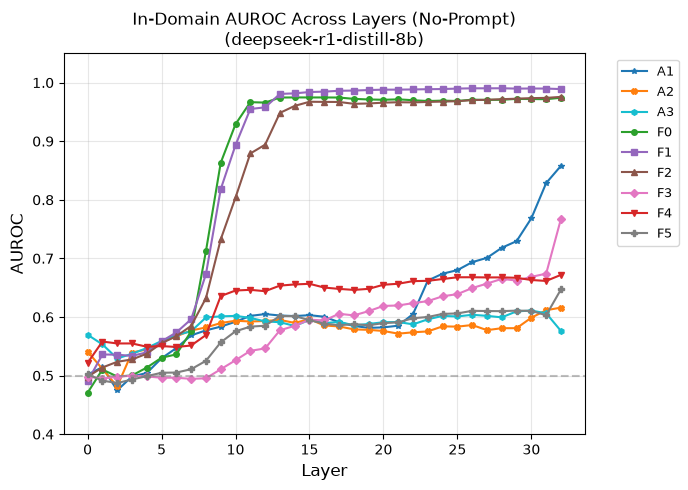

✓ Graph 1 saved: auroc_by_layer.png


In [8]:
# ============================================================================
# GRAPH 1: In-Domain AUROC for No-Prompt (by layer)
# ============================================================================

models = df['model'].unique()
print(f"Models in CSV: {models}")

fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5), sharey=True)

# Handle single model case
if len(models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models):
    model_data = no_prompt_data[no_prompt_data['model'] == model_name]
    
    for task_name in sorted(model_data["train_task"].unique()):
        task_data = model_data[model_data["train_task"] == task_name].sort_values("layer")
        layers = task_data["layer"].values
        aurocs = task_data["auroc"].values
        
        style = style_map.get(task_name, {"color": None, "marker": "o"})
        ax.plot(layers, aurocs, color=style["color"], marker=style["marker"],
                markersize=4, linewidth=1.5, label=task_name)
    
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Layer", fontsize=12)
    ax.set_ylabel("AUROC", fontsize=12)
    ax.set_title(f"In-Domain AUROC Across Layers (No-Prompt)\n({model_name})", fontsize=12)
    ax.set_ylim(0.4, 1.05)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("auroc_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Graph 1 saved: auroc_by_layer.png")


Models in COT-zero-shot data: <StringArray>
['deepseek-r1-distill-8b']
Length: 1, dtype: str


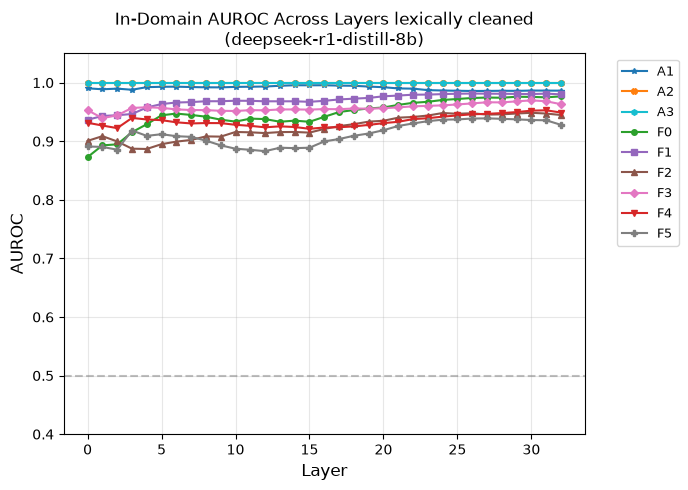

✓ Graph 2 saved: auroc_by_layer_cot_lexically_cleaned.png


In [10]:
# ============================================================================
# GRAPH 2: In-Domain AUROC for COT-Zero-Shot (by layer)
# ============================================================================

cot_data = df[
    (df['train_task'] == df['test_task']) &
    (df['train_condition'] == 'cot-zero-shot') &
    (df['test_condition'] == 'cot-zero-shot')
].copy()

models_cot = cot_data['model'].unique()
print(f"\nModels in COT-zero-shot data: {models_cot}")

fig, axes = plt.subplots(1, len(models_cot), figsize=(7 * len(models_cot), 5), sharey=True)

if len(models_cot) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models_cot):
    model_data = cot_data[cot_data['model'] == model_name]

    for task_name in sorted(model_data["train_task"].unique()):
        task_data = model_data[model_data["train_task"] == task_name].sort_values("layer")
        layers = task_data["layer"].values
        aurocs = task_data["auroc"].values

        style = style_map.get(task_name, {"color": None, "marker": "o"})
        ax.plot(layers, aurocs, color=style["color"], marker=style["marker"],
                markersize=4, linewidth=1.5, label=task_name)

    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Layer", fontsize=12)
    ax.set_ylabel("AUROC", fontsize=12)
    ax.set_title(f"In-Domain AUROC Across Layers lexically cleaned\n({model_name})", fontsize=12)
    ax.set_ylim(0.4, 1.05)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("auroc_by_layer_cot_lexically_cleaned.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Graph 2 saved: auroc_by_layer_cot_lexically_cleaned.png")

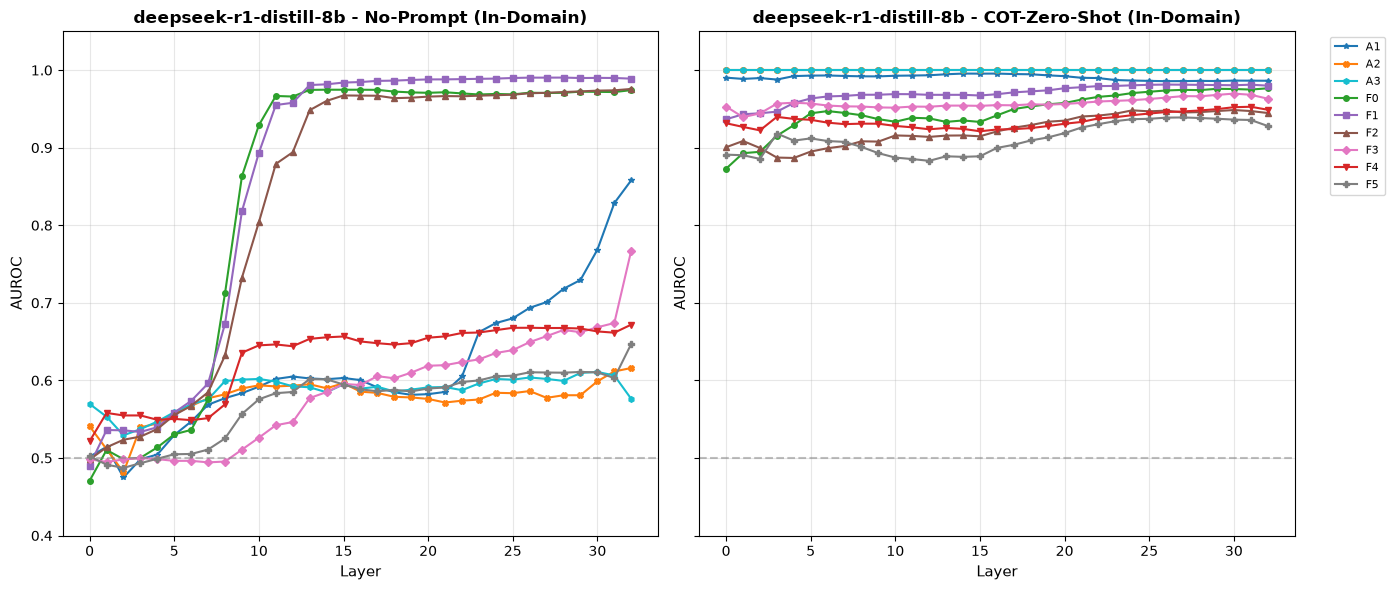

✓ Graph 3 saved: auroc_comparison_no_prompt_vs_cot.png


In [ ]:
# ============================================================================
# GRAPH 3: Comparison of No-Prompt vs COT-Zero-Shot (side-by-side)
# ============================================================================

no_prompt_data = df[
    (df['train_task'] == df['test_task']) &
    (df['train_condition'] == 'no-prompt') &
    (df['test_condition'] == 'no-prompt')
].copy()

all_models = sorted(df['model'].unique())
fig, axes = plt.subplots(len(all_models), 2, figsize=(14, 6 * len(all_models)), sharey='row')

if len(all_models) == 1:
    axes = axes.reshape(1, -1)

for row, model_name in enumerate(all_models):
    # Left: No-Prompt
    no_prompt_model = no_prompt_data[no_prompt_data['model'] == model_name]
    ax_left = axes[row, 0]

    for task_name in sorted(no_prompt_model["train_task"].unique()):
        task_data = no_prompt_model[no_prompt_model["train_task"] == task_name].sort_values("layer")
        layers = task_data["layer"].values
        aurocs = task_data["auroc"].values

        style = style_map.get(task_name, {"color": None, "marker": "o"})
        ax_left.plot(layers, aurocs, color=style["color"], marker=style["marker"],
                     markersize=4, linewidth=1.5, label=task_name)

    ax_left.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax_left.set_xlabel("Layer", fontsize=11)
    ax_left.set_ylabel("AUROC", fontsize=11)
    ax_left.set_title(f"{model_name} - No-Prompt (In-Domain)", fontsize=12, fontweight='bold')
    ax_left.set_ylim(0.4, 1.05)
    ax_left.grid(alpha=0.3)

    # Right: COT-Zero-Shot
    cot_model = cot_data[cot_data['model'] == model_name]
    ax_right = axes[row, 1]

    for task_name in sorted(cot_model["train_task"].unique()):
        task_data = cot_model[cot_model["train_task"] == task_name].sort_values("layer")
        layers = task_data["layer"].values
        aurocs = task_data["auroc"].values

        style = style_map.get(task_name, {"color": None, "marker": "o"})
        ax_right.plot(layers, aurocs, color=style["color"], marker=style["marker"],
                      markersize=4, linewidth=1.5, label=task_name)

    ax_right.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax_right.set_xlabel("Layer", fontsize=11)
    ax_right.set_ylabel("AUROC", fontsize=11)
    ax_right.set_title(f"{model_name} - COT-Zero-Shot (In-Domain)", fontsize=12, fontweight='bold')
    ax_right.set_ylim(0.4, 1.05)
    ax_right.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    ax_right.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("auroc_comparison_no_prompt_vs_cot.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Graph 3 saved: auroc_comparison_no_prompt_vs_cot.png")


Models in Sentence-Based-CoT data: <StringArray>
['deepseek-r1-distill-8b']
Length: 1, dtype: str


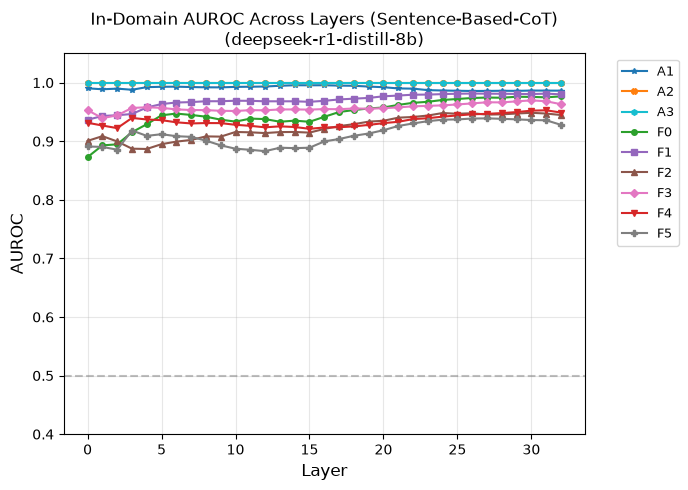

✓ Graph 4 saved: auroc_by_layer_sentence_based_cot.png


In [5]:
# ============================================================================
# GRAPH 4: In-Domain AUROC for Sentence-Based-CoT (by layer)
# ============================================================================

sentence_based_cot_data = df[
    (df['train_task'] == df['test_task']) &
    (df['train_condition'] == 'sentence-based-CoT') &
    (df['test_condition'] == 'sentence-based-CoT')
].copy()

models_sbc = sentence_based_cot_data['model'].unique()
print(f"\nModels in Sentence-Based-CoT data: {models_sbc}")

fig, axes = plt.subplots(1, len(models_sbc), figsize=(7 * len(models_sbc), 5), sharey=True)

if len(models_sbc) == 1:
    axes = [axes]

for ax, model_name in zip(axes, models_sbc):
    model_data = sentence_based_cot_data[sentence_based_cot_data['model'] == model_name]

    for task_name in sorted(model_data["train_task"].unique()):
        task_data = model_data[model_data["train_task"] == task_name].sort_values("layer")
        layers = task_data["layer"].values
        aurocs = task_data["auroc"].values

        style = style_map.get(task_name, {"color": None, "marker": "o"})
        ax.plot(layers, aurocs, color=style["color"], marker=style["marker"],
                markersize=4, linewidth=1.5, label=task_name)

    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Layer", fontsize=12)
    ax.set_ylabel("AUROC", fontsize=12)
    ax.set_title(f"In-Domain AUROC Across Layers (Sentence-Based-CoT)\n({model_name})", fontsize=12)
    ax.set_ylim(0.4, 1.05)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("auroc_by_layer_sentence_based_cot.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Graph 4 saved: auroc_by_layer_sentence_based_cot.png")

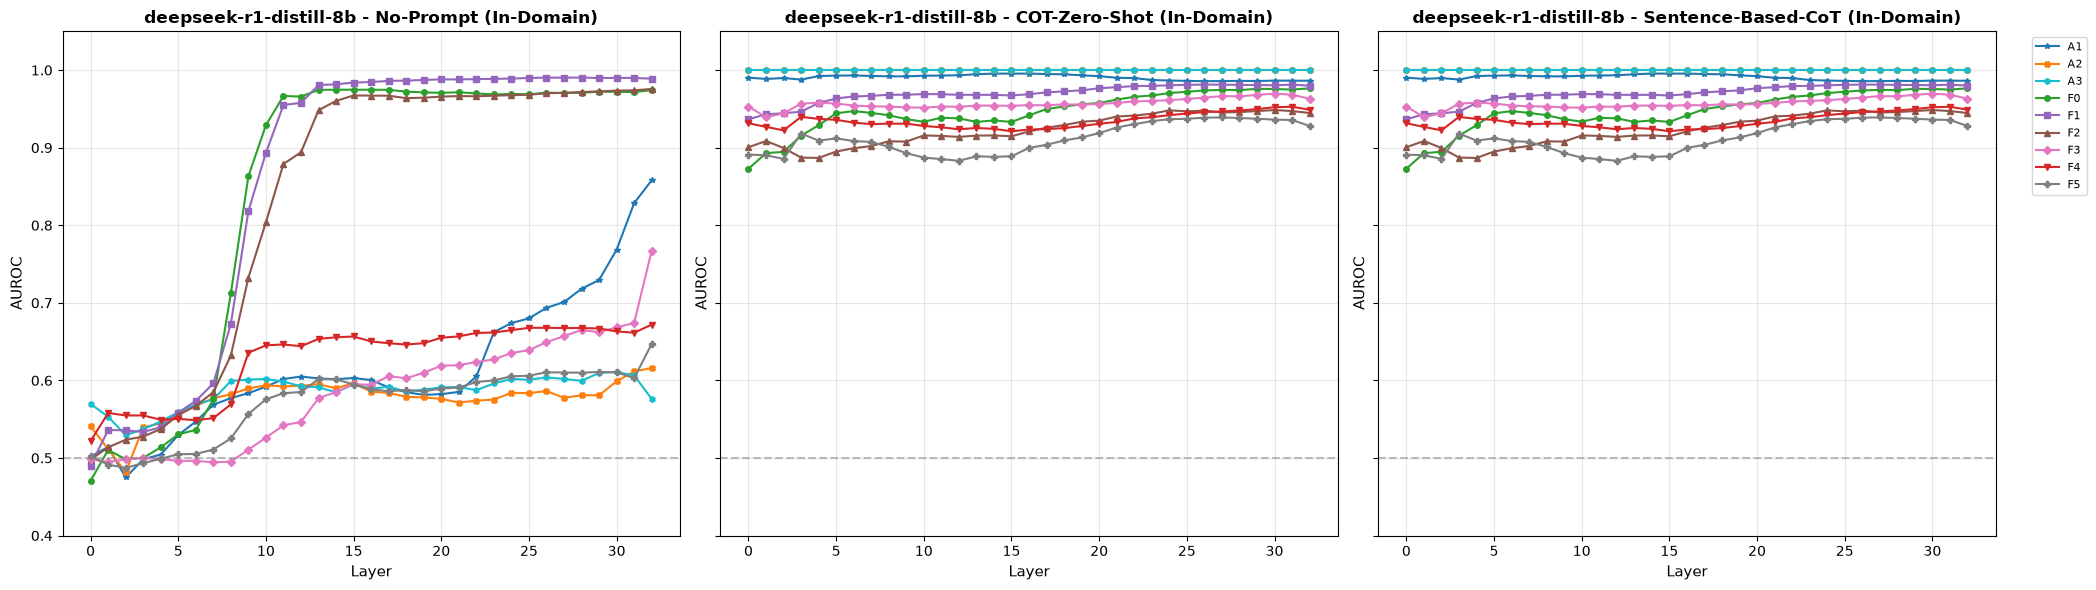

✓ Graph 5 saved: auroc_comparison_all_3_conditions.png


In [6]:
# ============================================================================
# GRAPH 5: Comparison of All 3 Conditions (No-Prompt vs COT-Zero-Shot vs Sentence-Based-CoT)
# ============================================================================

all_models = sorted(df['model'].unique())
fig, axes = plt.subplots(len(all_models), 3, figsize=(21, 6 * len(all_models)), sharey='row')

if len(all_models) == 1:
    axes = axes.reshape(1, -1)

for row, model_name in enumerate(all_models):
    conditions = [
        ('no-prompt', no_prompt_data, "No-Prompt"),
        ('cot-zero-shot', cot_data, "COT-Zero-Shot"),
        ('sentence-based-CoT', sentence_based_cot_data, "Sentence-Based-CoT")
    ]
    
    for col, (condition_key, condition_df, condition_label) in enumerate(conditions):
        ax = axes[row, col]
        model_data = condition_df[condition_df['model'] == model_name]

        for task_name in sorted(model_data["train_task"].unique()):
            task_data = model_data[model_data["train_task"] == task_name].sort_values("layer")
            layers = task_data["layer"].values
            aurocs = task_data["auroc"].values

            style = style_map.get(task_name, {"color": None, "marker": "o"})
            ax.plot(layers, aurocs, color=style["color"], marker=style["marker"],
                    markersize=4, linewidth=1.5, label=task_name)

        ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
        ax.set_xlabel("Layer", fontsize=11)
        ax.set_ylabel("AUROC", fontsize=11)
        ax.set_title(f"{model_name} - {condition_label} (In-Domain)", fontsize=12, fontweight='bold')
        ax.set_ylim(0.4, 1.05)
        if col == 2:
            ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("auroc_comparison_all_3_conditions.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Graph 5 saved: auroc_comparison_all_3_conditions.png")